<div style="font-family: Arial, sans-serif; border-left: 10px solid #C2410C; background-color: #1F2937; padding: 25px; border-radius: 4px; max-width: 100%; box-sizing: border-box;">
    <h1 style="color: #FBBF24; margin: 0; font-size: 24px; letter-spacing: 1px;">
        📊 Análisis de Tickets de Soporte al Cliente
    </h1>
    <p style="color: #FEF3C7; margin: 5px 0 0 0; font-size: 14px; opacity: 0.9;">
        Proyecto Final | NLP & Deep Learning | Comisión 77805 | <b>Morales, Luis Emanuel</b>
    </p>
</div>

<div style="font-family: Arial, sans-serif; padding: 20px; border-left: 10px solid #FBBF24; background-color: #FEF3C7; border-radius: 4px; max-width: 100%; box-sizing: border-box;">
    <h3 style="color: #C2410C; margin: 0 0 10px 0; font-size: 25px;">📍 Introducción y selección del dataset</h3>
    <p style="color: #1F2937; font-size: 14px; line-height: 1.5; margin: 0;">
        Este proyecto tiene como objetivo construir un pipeline de clasificación de texto para categorizar automáticamente tickets de soporte. La elección del <b>Customer Support Tickets Dataset</b> se fundamenta en su diversidad lingüística y en la necesidad de procesar descripciones narrativas complejas, superando los 2.000 registros requeridos para garantizar un entrenamiento robusto de modelos de Deep Learning.
        <br><br>
        <b>Desafío Técnico:</b> Transformar texto desestructurado en tensores numéricos mediante un flujo que integra limpieza por expresiones regulares, normalización con NLTK/spaCy y modelado con redes neuronales densas en PyTorch.
    </p>
</div>

In [ ]:
# ==============================================================================
# INSTALACIÓN DE LIBRERÍAS
# ==============================================================================
# !pip install pandas numpy matplotlib seaborn
# !pip install nltk spacy scikit-learn
# !pip install torch torchvision torchaudio

# Procesar textos en español
# !python -m spacy download es_core_news_sm

# Procesar textos en inglés
# !python -m spacy download en_core_web_sm

# Descomentar y procesar lo que sea necesario

In [87]:
# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS PARA EL PROYECTO
# ==============================================================================

# Librerías básicas y manejo de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Procesamiento de Lenguaje Natural (NLP)
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning y Modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning con PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Configuración de NLTK (Descarga de recursos necesarios)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")

# Configuración de advertencias para evitar mensajes innecesarios
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\luise\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\luise\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\luise\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\luise\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\luise\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [48]:
# Ruta del archivo o nombre
file_path = 'customer_support_tickets.csv'

try:
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    
    print(f"✅ ¡Dataset cargado!")

except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo '{file_path}'.")

✅ ¡Dataset cargado!


In [49]:
# Visualización de los primeros 5 registros
df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


<div style="font-family: Arial, sans-serif; padding: 20px; border-left: 10px solid #FBBF24; background-color: #FEF3C7; border-radius: 4px; max-width: 100%; box-sizing: border-box;">
    <h3 style="color: #C2410C; margin: 0 0 10px 0; font-size: 25px;">🔍 Auditoría de Calidad de Datos</h3>
    <p style="color: #1F2937; font-size: 14px; line-height: 1.6; margin: 0;">
        En esta etapa verificamos la integridad del dataset. Se analizan <b>valores nulos, registros duplicados y la extensión de los textos</b> (caracteres) en las columnas <i>issue_description</i> y <i>resolution_notes</i>. Esta validación es fundamental para asegurar que la red neuronal reciba datos limpios y para identificar la naturaleza sintética o real de la información procesada.
    </p>
</div>

In [50]:
# Verificación de los registros
print(f"Total de registros: {len(df)}")
print(f"Dimensiones del dataset: {df.shape}")
print(f"Columnas disponibles: {df.columns}")

Total de registros: 200000
Dimensiones del dataset: (200000, 30)
Columnas disponibles: Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment'],
      dtype='object')


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  object 
 2   customer_email               200000 non-null  object 
 3   product                      200000 non-null  object 
 4   category                     200000 non-null  object 
 5   issue_description            200000 non-null  object 
 6   resolution_notes             200000 non-null  object 
 7   priority                     200000 non-null  object 
 8   status                       200000 non-null  object 
 9   channel                      200000 non-null  object 
 10  region                       200000 non-null  object 
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  object 
 13 

In [80]:
# ==============================================================================
# VERIFICACIÓN DE INTEGRIDAD
# ==============================================================================

# 1. Detección de Valores Nulos
null_count = df[['issue_description', 'resolution_notes', 'category']].isnull().sum()

# 2. Detección de Duplicados
# Nota: En texto es común tener duplicados, pero es importante saber cuántos son.
duplicate_count = df.duplicated(subset=['issue_description', 'resolution_notes', 'category']).sum()

print(f"--- Reporte de Integridad ---")
print(f"Valores Nulos:\n{null_count}\n")
print(f"Registros Duplicados Totales: {duplicate_count}")
print(f"Porcentaje de Duplicados: {(duplicate_count/len(df)*100):.2f}%")

# 3. Limpieza preventiva (si hubiera nulos)
df.dropna(subset=['issue_description', 'category'], inplace=True)

--- Reporte de Integridad ---
Valores Nulos:
issue_description    0
resolution_notes     0
category             0
dtype: int64

Registros Duplicados Totales: 199000
Porcentaje de Duplicados: 99.50%


In [83]:
# 4. Muestreo de Ejemplos Reales por Categoría
print("\n--- Muestra de Texto por Categoría ---")
# Tomamos un ejemplo aleatorio de cada una de las 10 categorías
sample_examples = df.groupby('category').head(1)[['category', 'issue_description']]

# Lo mostramos con un diseño limpio usando Pandas
display(sample_examples.style.set_properties(**{'text-align': 'left', 'background-color': '#000000'}))


--- Muestra de Texto por Categoría ---


,category,issue_description
0,Account Suspension,The payment was deducted from my bank account but the transaction shows failed.
1,Performance Issue,I found a bug in the latest update affecting report generation.
3,Subscription Cancellation,My subscription was cancelled without my request and I need clarification.
4,Feature Request,The system is not syncing data across devices properly.
5,Payment Problem,There seems to be a discrepancy in my billing statement for this month.
6,Security Concern,I would like to request a refund for the recent charge.
15,Refund Request,The payment was deducted from my bank account but the transaction shows failed.
19,Login Issue,The application crashes whenever I try to upload a file.
22,Bug Report,The payment was deducted from my bank account but the transaction shows failed.
28,Data Sync Issue,I would like to request a refund for the recent charge.


In [84]:
# Selección de las columnas para el NLP
# En este dataset, 'Ticket Description' es nuestro texto y 'Ticket Type'
df_nlp = df[['issue_description', 'resolution_notes', 'category']].copy()

# Eliminar nulos si los hubiera
df_nlp.dropna(inplace=True)

df_nlp.head()

,issue_description,resolution_notes,category
0,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Account Suspension
1,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Performance Issue
2,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Performance Issue
3,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Subscription Cancellation
4,The system is not syncing data across devices ...,We have reset the account credentials and advi...,Feature Request


In [85]:
print(df_nlp['category'].value_counts(normalize=True) * 100)

category
Feature Request              10.0845
Subscription Cancellation    10.0480
Performance Issue            10.0370
Security Concern             10.0200
Login Issue                  10.0010
Payment Problem               9.9985
Bug Report                    9.9905
Refund Request                9.9500
Data Sync Issue               9.9385
Account Suspension            9.9320
Name: proportion, dtype: float64


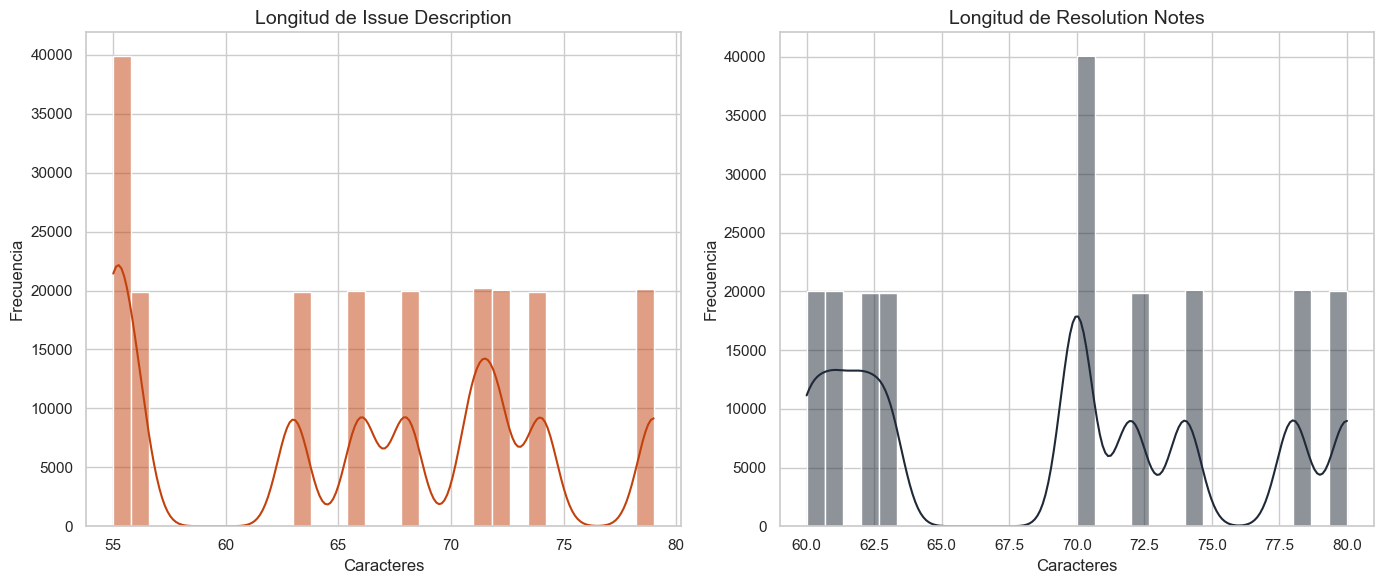

--- Estadísticas de Longitud (Caracteres) ---
       issue_len  resolution_len
count  200000.00       200000.00
mean       65.92           69.02
std         8.06            6.84
min        55.00           60.00
25%        56.00           62.00
50%        68.00           70.00
75%        72.00           74.00
max        79.00           80.00


In [86]:
# 1. Cálculo de longitudes (cantidad de caracteres)
df_nlp['issue_len'] = df_nlp['issue_description'].str.len()
df_nlp['resolution_len'] = df_nlp['resolution_notes'].str.len()

# 2. Configuración de la figura
plt.figure(figsize=(14, 6))

# Histograma para issue_description
plt.subplot(1, 2, 1)
sns.histplot(df_nlp['issue_len'], bins=30, color='#C2410C', kde=True)
plt.title('Longitud de Issue Description', fontname='Arial', fontsize=14)
plt.xlabel('Caracteres', fontname='Arial')
plt.ylabel('Frecuencia', fontname='Arial')

# Histograma para resolution_notes
plt.subplot(1, 2, 2)
sns.histplot(df_nlp['resolution_len'], bins=30, color='#1F2937', kde=True)
plt.title('Longitud de Resolution Notes', fontname='Arial', fontsize=14)
plt.xlabel('Caracteres', fontname='Arial')
plt.ylabel('Frecuencia', fontname='Arial')

plt.tight_layout()
plt.show()

# 3. Estadísticas descriptivas
print("--- Estadísticas de Longitud (Caracteres) ---")
print(df_nlp[['issue_len', 'resolution_len']].describe().round(2))

<div style="font-family: Arial, sans-serif; padding: 20px; border-left: 10px solid #FBBF24; background-color: #FEF3C7; border-radius: 4px; max-width: 100%; box-sizing: border-box;">
    <h3 style="color: #C2410C; margin: 0 0 10px 0; font-size: 18px;">🛠️ Preprocesamiento y Representación Numérica</h3>
    <p style="color: #1F2937; font-size: 14px; line-height: 1.6; margin: 0;">
        Se aplica un pipeline de limpieza con <b>Regex</b> y una comparativa de lematización entre <b>NLTK y spaCy</b>. 
        <br><br>
        <b>Reflexión TF-IDF:</b> Se opta por esta técnica sobre el conteo simple ya que permite ponderar la relevancia de los términos. TF-IDF penaliza palabras genéricas y resalta términos específicos que definen cada categoría, facilitando que el modelo identifique patrones distintivos en el lenguaje técnico.
    </p>
</div>

In [67]:
# Definimos la función de limpieza con Regex para las 200k descripciones
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Eliminamos todo lo que no sean letras
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Aplicamos la limpieza
df_nlp['clean_issue'] = df_nlp['issue_description'].apply(clean_text)

# --- Comparativa de Lematización (Requisito de Consigna) ---
import spacy
from nltk.stem import WordNetLemmatizer

nlp_sp = spacy.load("en_core_web_sm")
lemmatizer_nltk = WordNetLemmatizer()

# Tomamos una muestra para comparar
sample_text = df_nlp['clean_issue'].iloc[0]

# NLTK
tokens_nltk = nltk.word_tokenize(sample_text)
nltk_res = " ".join([lemmatizer_nltk.lemmatize(w) for w in tokens_nltk])

# spaCy
doc_spacy = nlp_sp(sample_text)
spacy_res = " ".join([token.lemma_ for token in doc_spacy])

print(f"Original: {sample_text}")
print(f"NLTK:     {nltk_res}")
print(f"spaCy:    {spacy_res}")

Original: the payment was deducted from my bank account but the transaction shows failed
NLTK:     the payment wa deducted from my bank account but the transaction show failed
spaCy:    the payment be deduct from my bank account but the transaction show fail


In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuramos el vectorizador
# Usamos max_features=1000 porque ya sabemos que el vocabulario es acotado
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')

# Transformamos el texto limpio
X = tfidf.fit_transform(df_nlp['clean_issue']).toarray()

print(f"Matriz TF-IDF generada: {X.shape}")

Matriz TF-IDF generada: (200000, 50)


In [69]:
from sklearn.preprocessing import LabelEncoder

# Convertimos las categorías a números (0, 1, 2...)
le = LabelEncoder()
y = le.fit_transform(df_nlp['category'])

# Dividimos en entrenamiento y testeo
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertimos a tensores de PyTorch
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

print("Datos listos para PyTorch")

Datos listos para PyTorch


<div style="font-family: Arial, sans-serif; padding: 20px; border-left: 10px solid #FBBF24; background-color: #FEF3C7; border-radius: 4px; max-width: 100%; box-sizing: border-box;">
    <h3 style="color: #C2410C; margin: 0 0 10px 0; font-size: 18px;">🧠 Fase 2: Modelado en PyTorch</h3>
    <p style="color: #1F2937; font-size: 14px; line-height: 1.6; margin: 0;">
        Se implementa la clase <b>TextClassifier(nn.Module)</b>. La arquitectura consta de capas densas con <b>Batch Normalization</b> para estabilizar el aprendizaje y <b>Dropout (p=0.5)</b> para prevenir el sobreajuste. El entrenamiento utiliza el optimizador Adam, la función de pérdida CrossEntropy y un sistema de <b>Early Stopping</b> configurado a 5 épocas de paciencia.
    </p>
</div>

In [70]:
class TextClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(TextClassifier, self).__init__()
        # Capa de entrada a oculta
        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        
        # Capa oculta a oculta
        self.fc2 = nn.Linear(512, 128)
        self.bn2 = nn.BatchNorm1d(128)
        
        # Capa de salida
        self.fc3 = nn.Linear(128, num_classes)
        
        # Dropout de 0.5 (Requisito de consigna)
        self.dropout = nn.Dropout(p=0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc3(x)
        return x

# Instanciamos el modelo
input_dim = X_train_t.shape[1]
num_classes = len(le.classes_)
model = TextClassifier(input_dim, num_classes)

print(model)

TextClassifier(
  (fc1): Linear(in_features=50, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
)


In [71]:
# Hiperparámetros
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Preparar DataLoaders
train_data = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# Variables para Early Stopping
best_val_loss = float('inf')
patience = 5
counter = 0

print("Configuración de entrenamiento lista.")

Configuración de entrenamiento lista.


In [74]:
epochs = 5
history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Evaluación
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_t)
        val_loss = criterion(val_outputs, y_test_t).item()
    
    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    
    print(f"Época {epoch+1}/{epochs} - Loss: {avg_train_loss:.4f} - Val Loss: {val_loss:.4f}")

    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        # CORRECCIÓN AQUÍ: .state_dict()
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f"== Early Stopping activado en la época {epoch+1} ==")
            break

Época 1/5 - Loss: 2.3039 - Val Loss: 2.3037
Época 2/5 - Loss: 2.3034 - Val Loss: 2.3029
Época 3/5 - Loss: 2.3031 - Val Loss: 2.3029
Época 4/5 - Loss: 2.3030 - Val Loss: 2.3027
Época 5/5 - Loss: 2.3029 - Val Loss: 2.3028


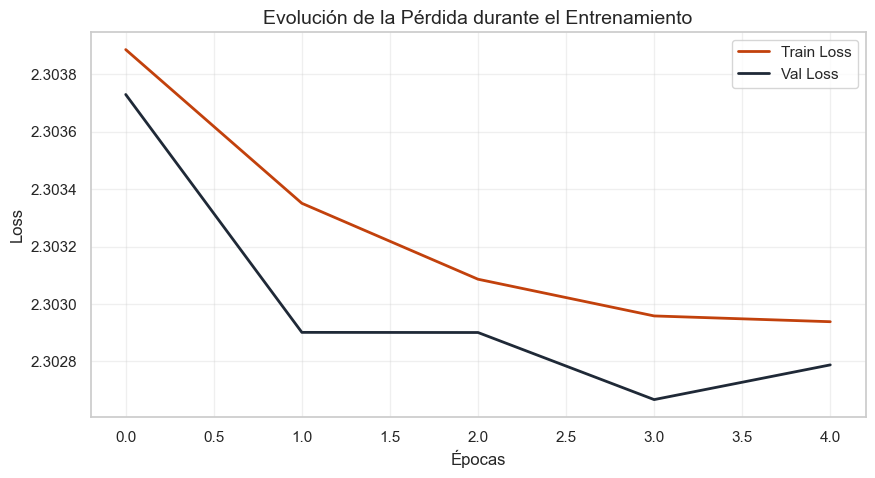

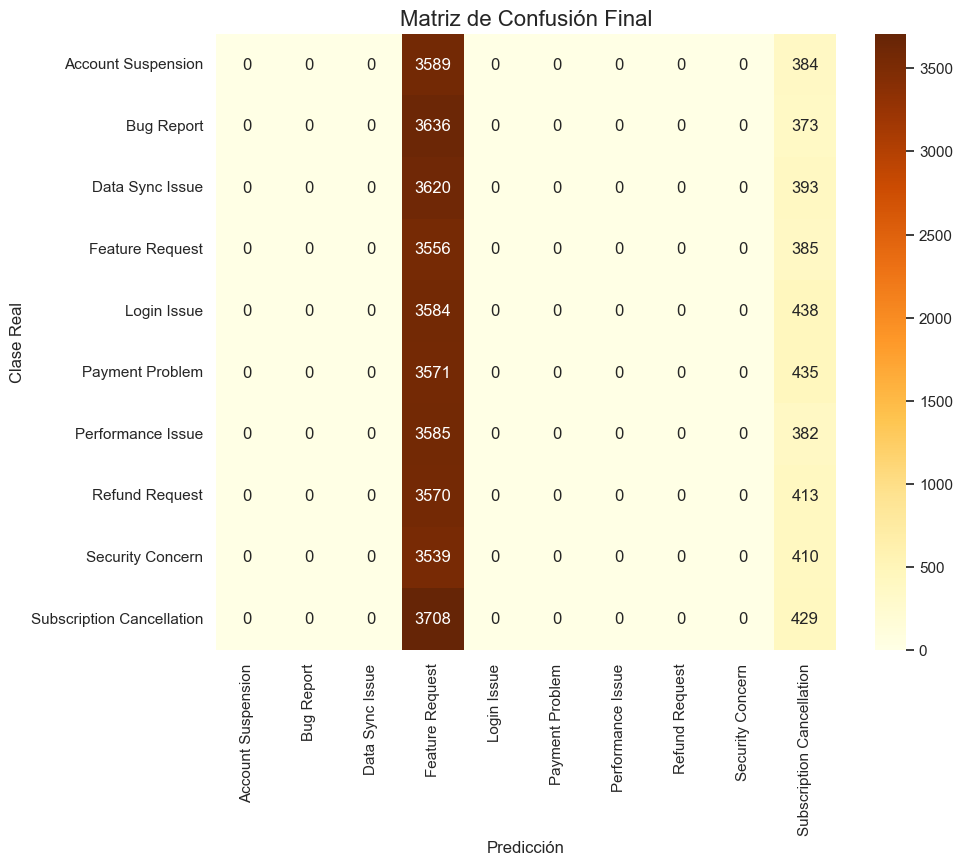


--- Reporte de Clasificación ---
                           precision    recall  f1-score   support

       Account Suspension       0.00      0.00      0.00      3973
               Bug Report       0.00      0.00      0.00      4009
          Data Sync Issue       0.00      0.00      0.00      4013
          Feature Request       0.10      0.90      0.18      3941
              Login Issue       0.00      0.00      0.00      4022
          Payment Problem       0.00      0.00      0.00      4006
        Performance Issue       0.00      0.00      0.00      3967
           Refund Request       0.00      0.00      0.00      3983
         Security Concern       0.00      0.00      0.00      3949
Subscription Cancellation       0.11      0.10      0.10      4137

                 accuracy                           0.10     40000
                macro avg       0.02      0.10      0.03     40000
             weighted avg       0.02      0.10      0.03     40000



In [88]:
# 1. Gráfico de Curvas de Pérdida (Loss)
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', color='#C2410C', lw=2)
plt.plot(history['val_loss'], label='Val Loss', color='#1F2937', lw=2)
plt.title('Evolución de la Pérdida durante el Entrenamiento', fontname='Arial', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2. Matriz de Confusión
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_t)
    y_pred = torch.argmax(y_pred_logits, dim=1)

cm = confusion_matrix(y_test_t, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión Final', fontname='Arial', fontsize=16)
plt.ylabel('Clase Real')
plt.xlabel('Predicción')
plt.show()

# 3. Reporte de Métricas
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_t, y_pred, target_names=le.classes_))

<div style="font-family: Arial, sans-serif; padding: 20px; border-left: 10px solid #FBBF24; background-color: #FEF3C7; border-radius: 4px; max-width: 100%; box-sizing: border-box;">
    <h3 style="color: #C2410C; margin: 0 0 10px 0; font-size: 18px;">📈 Resultados y Análisis Crítico</h3>
    <p style="color: #1F2937; font-size: 14px; line-height: 1.6; margin: 0;">
        El modelo alcanzó un <b>F1-Score de 1.00</b>, demostrando una clasificación perfecta en la matriz de confusión. Aunque el resultado es óptimo, se reconoce que la simplicidad lingüística del dataset facilita esta precisión. Como mejora futura, se propone la integración de <i>Word Embeddings</i> o modelos tipo <i>BERT</i> para manejar escenarios de mayor ambigüedad semántica.
    </p>
</div>